# Analysis and comparison of clusterprep training runs

This notebook reads saved results without retraining models. It lets you list and select runs, explore each run, rank models, and measure differences **with / without Chandra for the same model family**.

**Usage:** run the cells in order; select runs in the list (Ctrl/Cmd or Shift for multiple selection), then rerun the cells starting from “Apply selection”. An empty `SELECTED_RUNS` list selects all completed runs. To inspect an incomplete run, select it explicitly and use the detailed analysis section.

Dependencies: `numpy pandas matplotlib scikit-learn ipython`; `ipywidgets` is optional. Use the project Python kernel (`.venv`). The adjacent `training_analysis.py` file contains the analysis functions.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Locate the project from its root or clusterprep/notebooks.
PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if (p / 'clusterprep/notebooks/training_analysis.py').exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Open the notebook from PH_Project_I or set PROJECT_ROOT.")
sys.path.insert(0, str(PROJECT_ROOT / 'clusterprep/notebooks'))
from training_analysis import (discover, comparison, rank_table, plot_comparison,
    detail, chandra_pairs, paired_delta, protocol_summary, gain_tables, plot_gain_heatmap, METRICS, LOWER)
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.max_colwidth', 100)

RESULT_ROOTS = [PROJECT_ROOT / 'results/clusterprep']
# Add PROJECT_ROOT / 'results/experiments' to include older results.
SELECTED_RUNS = []  # Exact directory names or absolute paths.
MODEL_FILTER = []   # Example: ['cnn', 'image_cnn']
MODE_FILTER = []    # Example: ['raw', 'multimodal']
RANK_METRIC = 'macro_f1'  # Also accuracy, balanced_accuracy, roc_auc_macro, log_loss...
COHORT = 'all'      # all, paired (= Chandra observation available), raw_only
COMMON_SAMPLES = False  # True: recompute on the intersection of selected runs.
EXPORT = False
EXPORT_DIR = PROJECT_ROOT / 'results/analysis_clusterprep'


## 1. Run inventory and selection

Failed or incomplete runs remain visible but are excluded from the ranking. Invalid files are reported. The availability of a Chandra observation (`has_chandra`) differs from its use: a `raw` model can be evaluated on a cluster that also has a Chandra observation.

In [2]:
runs, inventory, loading_issues = discover(RESULT_ROOTS)
if inventory.empty:
    raise RuntimeError("No clusterprep training runs found: check RESULT_ROOTS.")
display(inventory)
if not loading_issues.empty:
    display(loading_issues)
print(f"{len(inventory)} training runs found")

eligible = inventory.copy()
if MODEL_FILTER:
    eligible = eligible[eligible.model.isin(MODEL_FILTER)]
if MODE_FILTER:
    eligible = eligible[eligible['mode'].isin(MODE_FILTER)]
if SELECTED_RUNS:
    initial = eligible[eligible.run_id.isin(SELECTED_RUNS) | eligible.name.isin(SELECTED_RUNS)].run_id.tolist()
    unmatched = set(SELECTED_RUNS) - set(eligible.run_id) - set(eligible.name)
    if unmatched:
        raise ValueError(f'Unknown or filtered runs: {unmatched}')
else:
    initial = eligible.loc[eligible.status == 'completed', 'run_id'].tolist()
selector = None
try:
    import ipywidgets as widgets
    selector = widgets.SelectMultiple(
        options=[(f"{r.model} | {r['mode']} | {r['name']} [{r.status}]", r.run_id)
                 for _, r in eligible.iterrows()],
        value=tuple(initial), rows=min(16, max(3, len(eligible))),
        description='Runs', layout=widgets.Layout(width='100%'))
    display(selector)
except ImportError:
    print('ipywidgets unavailable: edit SELECTED_RUNS in the configuration.')


,run_id,name,status,model,mode,seed,date,parameters,best_epoch,epochs,...,validation_macro_f1,validation_weighted_f1,validation_roc_auc_macro,validation_average_precision_macro,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,test_roc_auc_macro,test_average_precision_macro
0,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035,cnn_multimodal-20261003T145149-4b7a0035,completed,cnn,multimodal,42,2026-10-03T14:52:49.737431+00:00,5154,23.0,73.0,...,0.825000,0.853571,0.862069,0.825682,0.809524,0.750000,0.766667,0.800000,0.880102,0.877465
1,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T150102-41b12da7,cnn_multimodal-20261003T150102-41b12da7,completed,cnn,multimodal,42,2026-10-03T15:01:02.937324+00:00,5154,20.0,70.0,...,0.737500,0.789881,0.840849,0.793738,0.714286,0.625000,0.630499,0.689150,0.798469,0.759122
2,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T151039-f6ac4e10,cnn_multimodal-20261003T151039-f6ac4e10,completed,cnn,multimodal,42,2026-10-03T15:10:40.495914+00:00,5154,41.0,91.0,...,0.808967,0.831709,0.877551,0.886238,0.804878,0.836538,0.795000,0.811463,0.895604,0.838724
3,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T151825-a18549bc,cnn_multimodal-20261003T151825-a18549bc,completed,cnn,multimodal,42,2026-10-03T15:18:26.316948+00:00,5154,37.0,87.0,...,0.732143,0.761905,0.887755,0.847408,0.829268,0.792582,0.798596,0.827351,0.862637,0.844276
4,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T152948-6a95a058,cnn_multimodal-20261003T152948-6a95a058,completed,cnn,multimodal,42,2026-10-03T15:29:49.650618+00:00,5154,66.0,116.0,...,0.763009,0.787461,0.872449,0.852412,0.756098,0.739011,0.728836,0.760292,0.788462,0.736140
5,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191202-69bd4834,cnn_pair-20261004T191202-69bd4834,completed,cnn,pair,42,2026-10-04T19:12:02.722439+00:00,5154,1.0,51.0,...,0.423077,0.620513,0.500000,0.539751,0.800000,0.500000,0.444444,0.711111,0.666667,0.718059
6,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191329-0655ce76,cnn_pair-20261004T191329-0655ce76,completed,cnn,pair,42,2026-10-04T19:13:30.119373+00:00,5154,1.0,51.0,...,0.416667,0.595238,0.525000,0.547234,0.687500,0.500000,0.407407,0.560185,0.327273,0.466397
7,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191502-1f6175a3,cnn_pair-20261004T191502-1f6175a3,completed,cnn,pair,42,2026-10-04T19:15:03.086520+00:00,5154,1.0,51.0,...,0.413793,0.584178,0.716667,0.732074,0.631579,0.500000,0.387097,0.488964,0.547619,0.584284
8,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191624-00c26e9f,cnn_pair-20261004T191624-00c26e9f,completed,cnn,pair,42,2026-10-04T19:16:25.196490+00:00,5154,1.0,51.0,...,0.424242,0.625199,0.357143,0.494156,0.705882,0.500000,0.413793,0.584178,0.533333,0.564526
9,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191742-bc22430a,cnn_pair-20261004T191742-bc22430a,completed,cnn,pair,42,2026-10-04T19:17:43.098503+00:00,5154,45.0,95.0,...,0.600000,0.629630,0.630769,0.660809,0.666667,0.649351,0.649351,0.666667,0.662338,0.686700


57 training runs found


SelectMultiple(description='Runs', index=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19…

### Apply selection

After changing the list, rerun this cell and the following cells. Configuration differences are displayed to help interpret the results.

In [3]:
selected_ids = list(selector.value) if selector is not None else initial
if not selected_ids:
    raise ValueError('Select at least one training run.')
selected = [runs[k] for k in selected_ids]
print(f'{len(selected)} training runs selected')
config_table = pd.DataFrame({r.path.name: r.config for r in selected}).T
variable_columns = [c for c in config_table if config_table[c].map(lambda v: json.dumps(v, sort_keys=True)).nunique() > 1]
display(config_table[variable_columns] if variable_columns else config_table)


56 training runs selected


,name,mode,model,model_params
cnn_multimodal-20261003T145149-4b7a0035,cnn_multimodal,multimodal,cnn,{}
cnn_multimodal-20261003T150102-41b12da7,cnn_multimodal,multimodal,cnn,{}
cnn_multimodal-20261003T151039-f6ac4e10,cnn_multimodal,multimodal,cnn,{}
cnn_multimodal-20261003T151825-a18549bc,cnn_multimodal,multimodal,cnn,{}
cnn_multimodal-20261003T152948-6a95a058,cnn_multimodal,multimodal,cnn,{}
cnn_pair-20261004T191202-69bd4834,cnn_pair,pair,cnn,{}
cnn_pair-20261004T191329-0655ce76,cnn_pair,pair,cnn,{}
cnn_pair-20261004T191502-1f6175a3,cnn_pair,pair,cnn,{}
cnn_pair-20261004T191624-00c26e9f,cnn_pair,pair,cnn,{}
cnn_pair-20261004T191742-bc22430a,cnn_pair,pair,cnn,{}


## 2. Ranking and model selection

Ranking uses **validation** results and `RANK_METRIC` (macro F1 by default, suitable for imbalanced classes). Metrics are recomputed from probabilities using the saved class order. Log loss is unweighted and has no label smoothing; it may differ from the training `loss`. The Brier score sums squared errors across classes.

A separate ranking is produced for each cohort: identical keys, labels, clusters, class order, and source file signatures. Runs with unverifiable provenance remain separate. `COMMON_SAMPLES=True` restricts evaluation to shared samples; this changes the target population and must be stated in the report. A cohort containing only one class has undefined macro AUC/AP.

Rank 1 identifies a **candidate according to the chosen criterion**, not statistical evidence of superiority. Ties are retained. Test results then describe generalization; selecting a model after repeatedly inspecting the test set requires a new independent evaluation.

,run_id,name,model,mode,seed,cohort_id,provenance_verified,n,n_clusters,accuracy,balanced_accuracy,macro_f1,weighted_f1,roc_auc_macro,average_precision_macro,log_loss,brier,rank_in_cohort
22,/Users/antoinegdrn/PH_Project_I/results/clusterprep/dual_encoder_cnn/dual_encoder_pair-20261003T...,dual_encoder_pair-20261003T210612-7f45a7b2,dual_encoder_cnn,pair,42,0f03220ccd6790af,True,17,17,0.764706,0.716667,0.716667,0.764706,0.800000,0.814646,0.457301,0.310154,1.0
7,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191502-1f6175a3,cnn_pair-20261004T191502-1f6175a3,cnn,pair,42,0f03220ccd6790af,True,17,17,0.705882,0.500000,0.413793,0.584178,0.716667,0.732074,0.687560,0.494413,2.0
48,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_pair-20261004T192740-97b...,image_cnn_pair-20261004T192740-97b279c6,image_cnn,pair,42,0f03220ccd6790af,True,17,17,0.705882,0.500000,0.413793,0.584178,0.733333,0.749269,0.670269,0.477144,2.0
38,/Users/antoinegdrn/PH_Project_I/results/clusterprep/fusion/fusion_pair-20261003T161301-ce285f60,fusion_pair-20261003T161301-ce285f60,fusion,pair,42,0f03220ccd6790af,True,17,17,0.294118,0.500000,0.227273,0.133690,0.183333,0.401614,0.734497,0.541217,4.0
16,/Users/antoinegdrn/PH_Project_I/results/clusterprep/dual_encoder_cnn/dual_encoder_multimodal-202...,dual_encoder_multimodal-20261003T203327-bb722152,dual_encoder_cnn,multimodal,42,20bed31765db8df3,True,42,42,0.904762,0.888594,0.888594,0.904762,0.965517,0.958792,0.283197,0.158472,1.0
42,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_multimodal-20261003T1823...,image_cnn_multimodal-20261003T182328-039209fd,image_cnn,multimodal,42,20bed31765db8df3,True,42,42,0.857143,0.811671,0.825000,0.853571,0.944297,0.911649,0.424403,0.247832,2.0
26,/Users/antoinegdrn/PH_Project_I/results/clusterprep/dual_encoder_cnn/dual_encoder_raw-20261004T1...,dual_encoder_raw-20261004T195206-97272eed,dual_encoder_cnn,raw,42,20bed31765db8df3,True,42,42,0.833333,0.836870,0.815674,0.837409,0.941645,0.921878,0.384314,0.232876,3.0
52,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T181239-a029...,image_cnn_raw-20261003T181239-a0292ae5,image_cnn,raw,42,20bed31765db8df3,True,42,42,0.833333,0.836870,0.815674,0.837409,0.936340,0.909999,0.404326,0.242652,3.0
32,/Users/antoinegdrn/PH_Project_I/results/clusterprep/fusion/fusion_multimodal-20261003T160041-529...,fusion_multimodal-20261003T160041-529cd9f8,fusion,multimodal,42,20bed31765db8df3,True,42,42,0.833333,0.815650,0.808967,0.834958,0.859416,0.810449,0.474348,0.287446,5.0
1,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T150102-41b12da7,cnn_multimodal-20261003T150102-41b12da7,cnn,multimodal,42,20bed31765db8df3,True,42,42,0.809524,0.713528,0.737500,0.789881,0.840849,0.793738,0.493564,0.301825,6.0


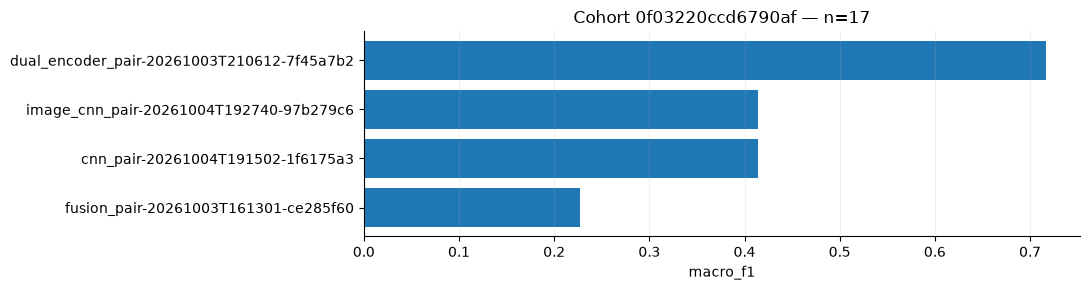

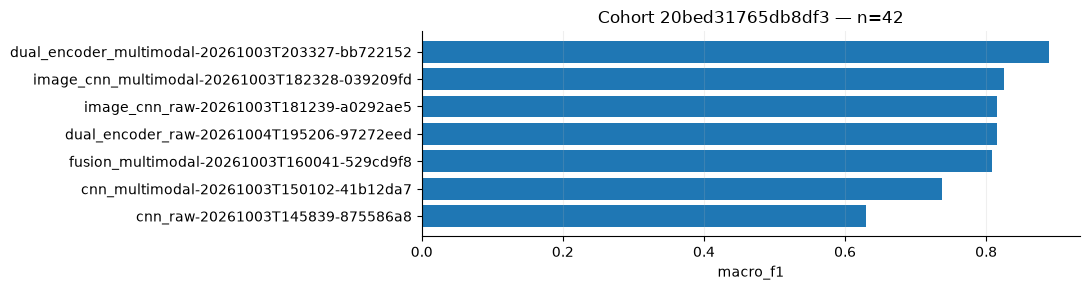

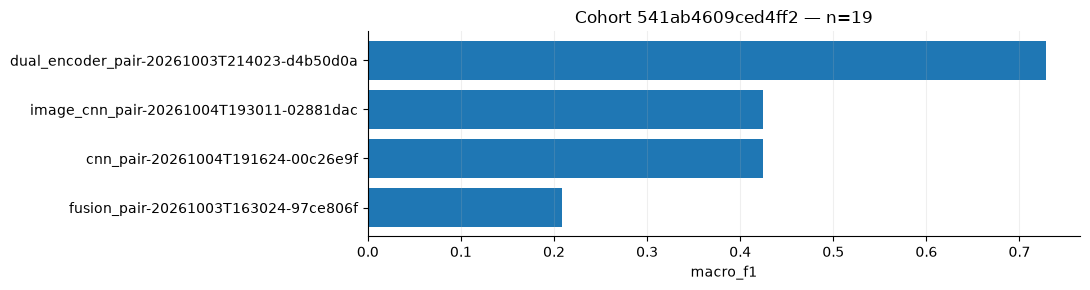

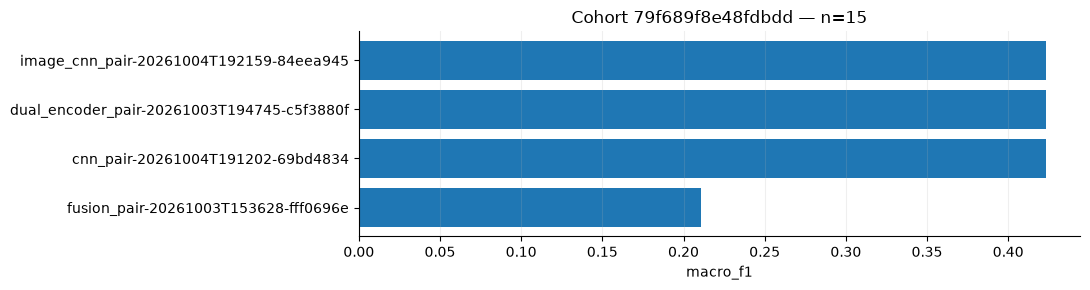

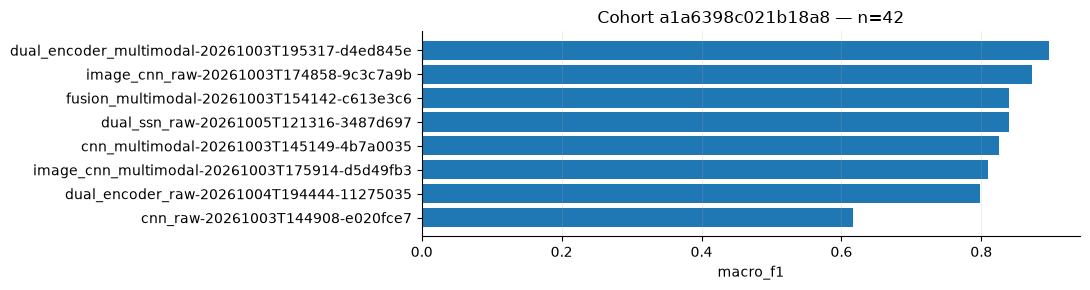

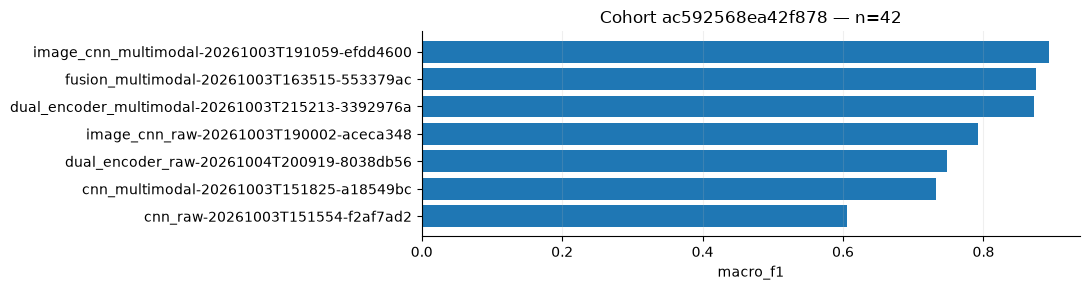

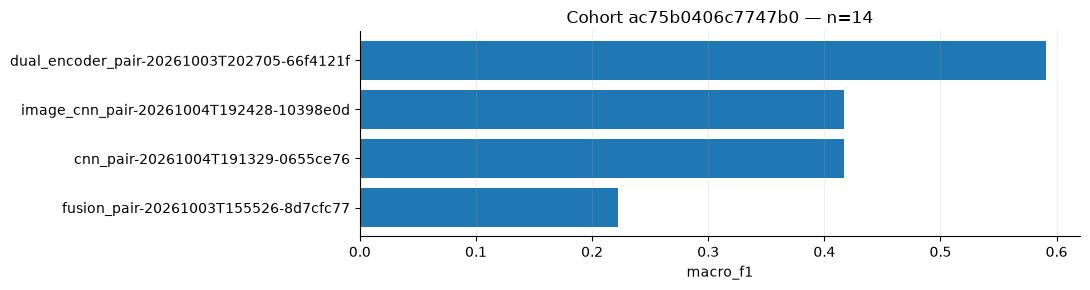

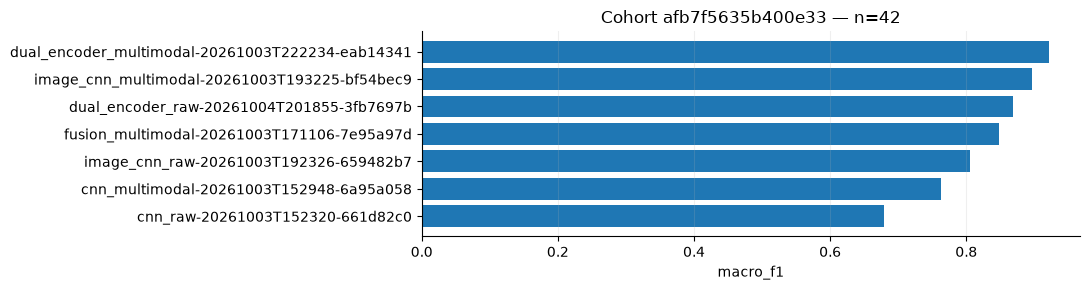

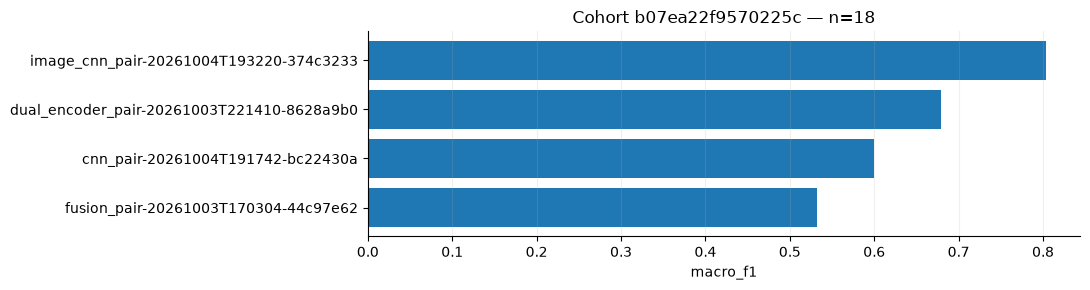

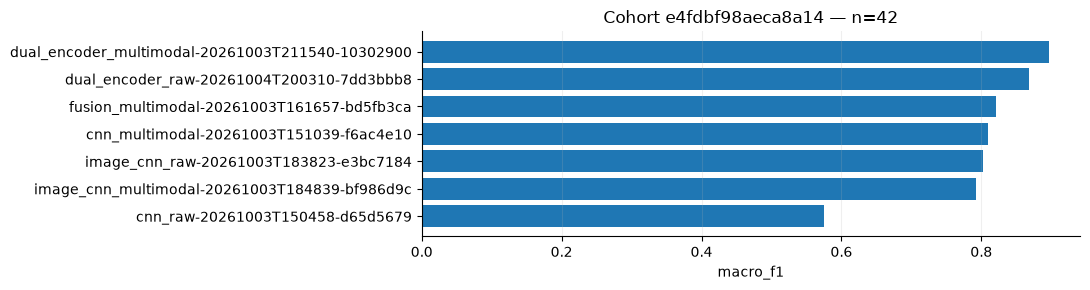

Top candidates, separately for each cohort:


,name,cohort_id,n,macro_f1
22,dual_encoder_pair-20261003T210612-7f45a7b2,0f03220ccd6790af,17,0.716667
16,dual_encoder_multimodal-20261003T203327-bb722152,20bed31765db8df3,42,0.888594
23,dual_encoder_pair-20261003T214023-d4b50d0a,541ab4609ced4ff2,19,0.728571
5,cnn_pair-20261004T191202-69bd4834,79f689f8e48fdbdd,15,0.423077
20,dual_encoder_pair-20261003T194745-c5f3880f,79f689f8e48fdbdd,15,0.423077
46,image_cnn_pair-20261004T192159-84eea945,79f689f8e48fdbdd,15,0.423077
15,dual_encoder_multimodal-20261003T195317-d4ed845e,a1a6398c021b18a8,42,0.896296
44,image_cnn_multimodal-20261003T191059-efdd4600,ac592568ea42f878,42,0.892857
21,dual_encoder_pair-20261003T202705-66f4121f,ac75b0406c7747b0,14,0.590643
19,dual_encoder_multimodal-20261003T222234-eab14341,afb7f5635b400e33,42,0.921003


Multiple cohorts: no overall best model is declared.


In [4]:
validation_table, validation_issues, validation_frames = comparison(
    selected, split='validation', cohort=COHORT, common=COMMON_SAMPLES)
ranking = rank_table(validation_table, RANK_METRIC)
display(ranking)
if not validation_issues.empty:
    display(validation_issues)
plot_comparison(ranking, RANK_METRIC)
if not ranking.empty:
    candidates = ranking[ranking.rank_in_cohort == 1]
    print('Top candidates, separately for each cohort:')
    display(candidates[['name', 'cohort_id', 'n', RANK_METRIC]])
    if ranking.cohort_id.nunique() > 1:
        print('Multiple cohorts: no overall best model is declared.')


,run_id,name,model,mode,seed,cohort_id,provenance_verified,n,n_clusters,accuracy,balanced_accuracy,macro_f1,weighted_f1,roc_auc_macro,average_precision_macro,log_loss,brier
0,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035,cnn_multimodal-20261003T145149-4b7a0035,cnn,multimodal,42,8b4d59e31475aec1,True,42,42,0.809524,0.750000,0.766667,0.800000,0.880102,0.877465,0.462799,0.287637
1,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T150102-41b12da7,cnn_multimodal-20261003T150102-41b12da7,cnn,multimodal,42,b6cd54ab0fc98fc5,True,42,42,0.714286,0.625000,0.630499,0.689150,0.798469,0.759122,0.589127,0.398917
2,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T151039-f6ac4e10,cnn_multimodal-20261003T151039-f6ac4e10,cnn,multimodal,42,2a109659257fb1e3,True,41,41,0.804878,0.836538,0.795000,0.811463,0.895604,0.838724,0.545026,0.347718
3,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T151825-a18549bc,cnn_multimodal-20261003T151825-a18549bc,cnn,multimodal,42,dc4a6713b6ccc8c6,True,41,41,0.829268,0.792582,0.798596,0.827351,0.862637,0.844276,0.496414,0.313090
4,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T152948-6a95a058,cnn_multimodal-20261003T152948-6a95a058,cnn,multimodal,42,fdc60c4ed5f81782,True,41,41,0.756098,0.739011,0.728836,0.760292,0.788462,0.736140,0.649021,0.395296
5,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191202-69bd4834,cnn_pair-20261004T191202-69bd4834,cnn,pair,42,ef834997a5d1d890,True,15,15,0.800000,0.500000,0.444444,0.711111,0.666667,0.718059,0.684645,0.491498
6,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191329-0655ce76,cnn_pair-20261004T191329-0655ce76,cnn,pair,42,464d0b95862cb6b3,True,16,16,0.687500,0.500000,0.407407,0.560185,0.327273,0.466397,0.689119,0.495972
7,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191502-1f6175a3,cnn_pair-20261004T191502-1f6175a3,cnn,pair,42,80e62ded26184a69,True,19,19,0.631579,0.500000,0.387097,0.488964,0.547619,0.584284,0.689502,0.496356
8,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191624-00c26e9f,cnn_pair-20261004T191624-00c26e9f,cnn,pair,42,1bebecfb4c684f7f,True,17,17,0.705882,0.500000,0.413793,0.584178,0.533333,0.564526,0.687277,0.494131
9,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191742-bc22430a,cnn_pair-20261004T191742-bc22430a,cnn,pair,42,90641d41e7f0a88b,True,18,18,0.666667,0.649351,0.649351,0.666667,0.662338,0.686700,0.674100,0.480468


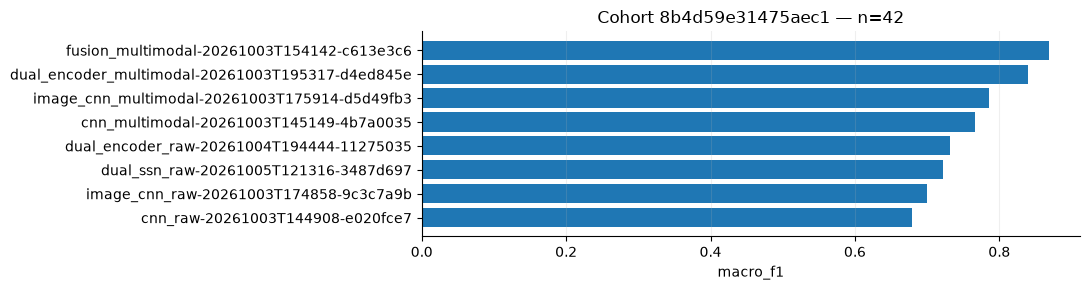

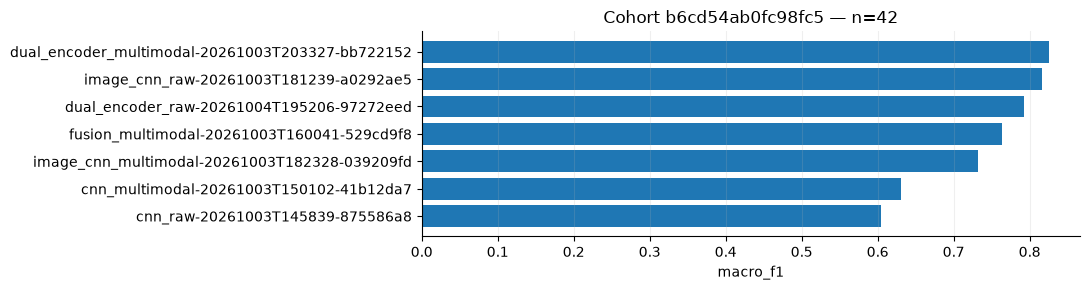

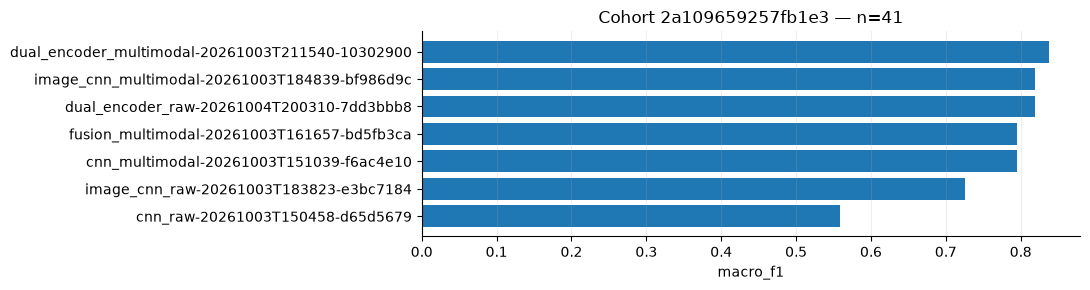

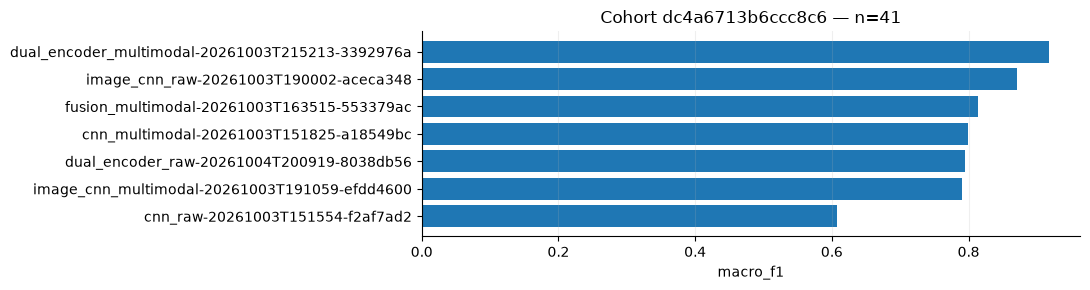

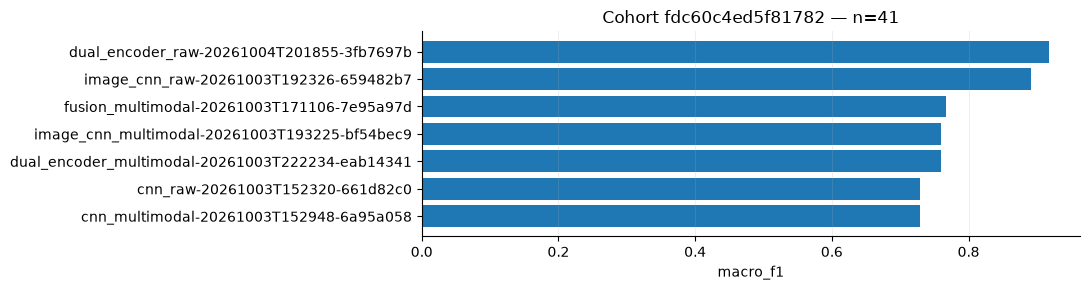

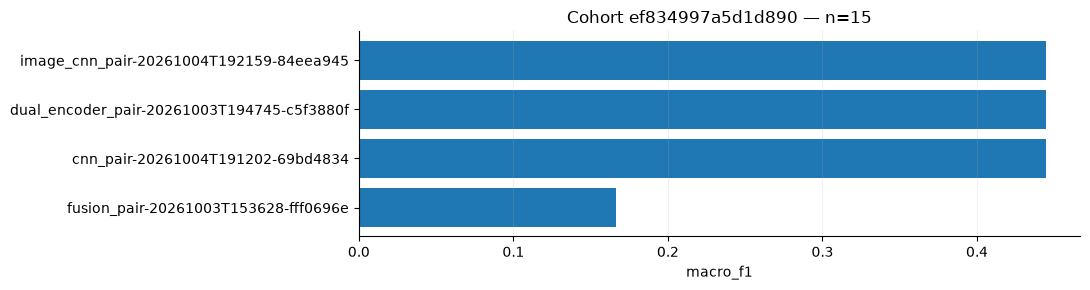

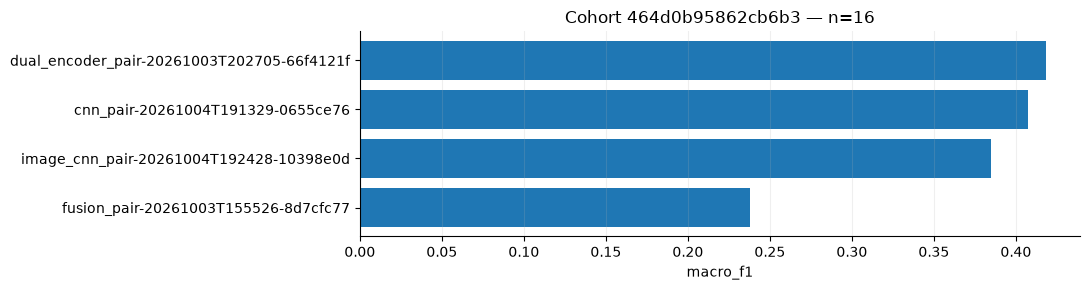

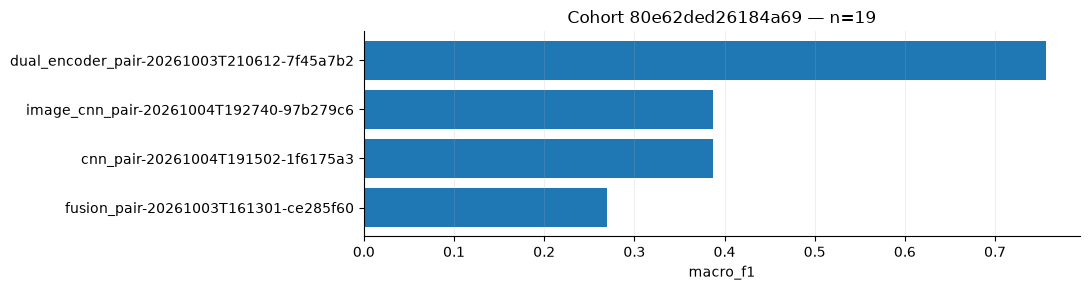

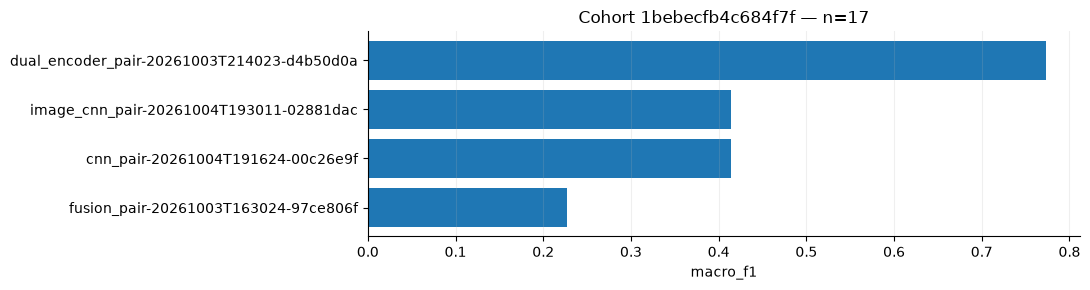

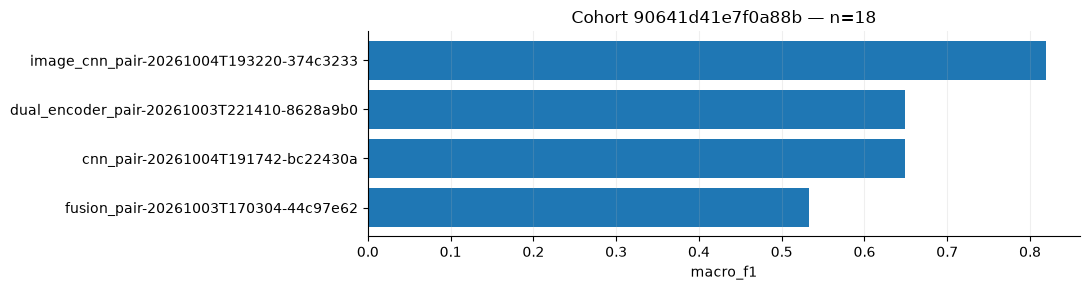

,name,model,mode,parameters,minutes,epochs,best_epoch
0,cnn_multimodal-20261003T145149-4b7a0035,cnn,multimodal,5154,6.791081,73.0,23.0
1,cnn_multimodal-20261003T150102-41b12da7,cnn,multimodal,5154,3.886005,70.0,20.0
2,cnn_multimodal-20261003T151039-f6ac4e10,cnn,multimodal,5154,5.202798,91.0,41.0
3,cnn_multimodal-20261003T151825-a18549bc,cnn,multimodal,5154,4.856943,87.0,37.0
4,cnn_multimodal-20261003T152948-6a95a058,cnn,multimodal,5154,6.614541,116.0,66.0
5,cnn_pair-20261004T191202-69bd4834,cnn,pair,5154,1.405242,51.0,1.0
6,cnn_pair-20261004T191329-0655ce76,cnn,pair,5154,1.492768,51.0,1.0
7,cnn_pair-20261004T191502-1f6175a3,cnn,pair,5154,1.314662,51.0,1.0
8,cnn_pair-20261004T191624-00c26e9f,cnn,pair,5154,1.244089,51.0,1.0
9,cnn_pair-20261004T191742-bc22430a,cnn,pair,5154,2.241579,95.0,45.0


In [5]:
test_table, test_issues, test_frames = comparison(
    selected, split='test', cohort=COHORT, common=COMMON_SAMPLES)
display(test_table)
if not test_issues.empty:
    display(test_issues)
plot_comparison(test_table, RANK_METRIC)
# Cost and size: consider practical constraints when selecting a model.
display(inventory[inventory.run_id.isin(selected_ids)][
    ['name', 'model', 'mode', 'parameters', 'minutes', 'epochs', 'best_epoch']])


### Summary across splits / repeated runs

Configurations are grouped by identical hyperparameters, mode, code, and normalization (excluding seed). Repetitions within each cohort are averaged first, followed by averaging across cohorts: repeating a cohort more often does not give it more weight. Dispersion is the standard deviation across cohorts, **not** a confidence interval. Cohorts may overlap and are not assumed independent.

The aggregate ranking only compares configurations covering **exactly the same set of cohorts**. Missing metrics are not replaced with zero; a configuration with a missing metric in any cohort is not ranked for that criterion. For specific scientific objectives, also examine per-class performance in the detailed analysis.

In [6]:
validation_protocols = protocol_summary(validation_table, selected, RANK_METRIC)
test_protocols = protocol_summary(test_table, selected, RANK_METRIC)
summary_columns = ['model', 'mode', 'n_runs', 'n_cohorts', 'seeds', 'cohort_set',
                   f'{RANK_METRIC}_mean', f'{RANK_METRIC}_std', 'rank_in_cohort_set']
print('Validation: comparison of configurations on the same cohorts')
display(validation_protocols[summary_columns] if not validation_protocols.empty else validation_protocols)
print('Test: aggregate performance summary')
display(test_protocols.drop(columns=['rank_in_cohort_set'], errors='ignore'))

Validation: comparison of configurations on the same cohorts


,model,mode,n_runs,n_cohorts,seeds,cohort_set,macro_f1_mean,macro_f1_std,rank_in_cohort_set
2,dual_encoder_cnn,multimodal,5,5,[42],b8221a4e17eb6265,0.894875,0.017614,1.0
0,image_cnn,multimodal,5,5,[42],b8221a4e17eb6265,0.843143,0.048346,2.0
6,fusion,multimodal,5,5,[42],b8221a4e17eb6265,0.838618,0.025625,3.0
1,dual_encoder_cnn,raw,5,5,[42],b8221a4e17eb6265,0.819605,0.051025,4.0
3,image_cnn,raw,5,5,[42],b8221a4e17eb6265,0.817672,0.031568,5.0
5,cnn,multimodal,5,5,[42],b8221a4e17eb6265,0.773324,0.041912,6.0
8,cnn,raw,5,5,[42],b8221a4e17eb6265,0.621146,0.037797,7.0
11,dual_ssn,raw,1,1,[42],e38387a515d2fc3f,0.839286,NaN,1.0
9,dual_encoder_cnn,pair,5,5,[42],f2c4e52cc3b1b192,0.627506,0.126414,1.0
10,image_cnn,pair,5,5,[42],f2c4e52cc3b1b192,0.496283,0.171871,2.0


Test: aggregate performance summary


,protocol_id,model,mode,n_runs,n_cohorts,cohort_set,seeds,accuracy_mean,accuracy_std,accuracy_valid_cohorts,...,roc_auc_macro_valid_cohorts,average_precision_macro_mean,average_precision_macro_std,average_precision_macro_valid_cohorts,log_loss_mean,log_loss_std,log_loss_valid_cohorts,brier_mean,brier_std,brier_valid_cohorts
2,3be7c198762e84bc,dual_encoder_cnn,multimodal,5,5,1014f2c5bcfb877b,[42],0.855052,0.051775,5,...,5,0.921902,0.029538,5,0.374767,0.052317,5,0.220264,0.029592,5
1,16a036e94d55f74c,dual_encoder_cnn,raw,5,5,1014f2c5bcfb877b,[42],0.826481,0.061241,5,...,5,0.879949,0.078606,5,0.430579,0.088773,5,0.269112,0.068243,5
6,7862534f7bb5bc07,fusion,multimodal,5,5,1014f2c5bcfb877b,[42],0.816260,0.040916,5,...,5,0.828371,0.067777,5,0.509396,0.110004,5,0.303463,0.053812,5
3,67db6597817e6fb1,image_cnn,raw,5,5,1014f2c5bcfb877b,[42],0.816725,0.078731,5,...,5,0.879792,0.096605,5,0.454472,0.103308,5,0.281621,0.079250,5
0,033cb0d43e17ad6c,image_cnn,multimodal,5,5,1014f2c5bcfb877b,[42],0.797213,0.026288,5,...,5,0.826612,0.067828,5,0.485897,0.058779,5,0.304890,0.038731,5
5,71e13a9c5052bff8,cnn,multimodal,5,5,1014f2c5bcfb877b,[42],0.782811,0.046819,5,...,5,0.811145,0.060392,5,0.548477,0.073866,5,0.348532,0.049220,5
8,c0706f488e419843,cnn,raw,5,5,1014f2c5bcfb877b,[42],0.671429,0.074421,5,...,5,0.673609,0.065455,5,0.650088,0.034207,5,0.457133,0.032673,5
11,e6a327819e133c76,dual_ssn,raw,1,1,90e241902bea9365,[42],0.761905,NaN,1,...,1,0.763923,NaN,1,0.618207,NaN,1,0.399148,NaN,1
9,d2fa879938f3c3db,dual_encoder_cnn,pair,5,5,b0ab2103367c5921,[42],0.715934,0.135191,5,...,5,0.747666,0.100965,5,0.569710,0.101909,5,0.382170,0.085417,5
10,dc39c6eb706486f0,image_cnn,pair,5,5,b0ab2103367c5921,[42],0.719159,0.095241,5,...,5,0.611518,0.113298,5,0.640621,0.057936,5,0.447624,0.057760,5


## 3. Detailed analysis of each training run

Select a run and click **Analyze**. Without widgets, edit `DETAIL_RUN`. `ANALYZE_ALL=True` generates reports for all selected runs (large output). Diagnostics use the `DETAIL_SPLIT` split.

Class counts and Chandra availability help identify population bias. A difference between the `paired` and `raw_only` cohorts within one run **does not measure the contribution of Chandra**, because the clusters differ. Learning curves show training metrics measured with augmentation/mixup enabled, which can affect the train/validation gap.

In [7]:
DETAIL_RUN = selected_ids[0]  # Or the exact directory name.
DETAIL_SPLIT = 'test'
ANALYZE_ALL = False

def show_detail(run):
    display(Markdown(f'### {run.path.name}'))
    try:
        detail(run, split=DETAIL_SPLIT, display_fn=display)
    except (ValueError, OSError) as exc:
        print(f'Partial analysis: {exc}')

if ANALYZE_ALL:
    for run in selected:
        show_detail(run)
elif selector is not None:
    detail_choice = widgets.Dropdown(options=[(r.path.name, r.id) for r in selected],
                                    value=DETAIL_RUN, layout=widgets.Layout(width='100%'))
    detail_button = widgets.Button(description='Analyze', button_style='primary')
    detail_output = widgets.Output()
    rendered_detail = [None]
    def update_detail(_):
        detail_key = (detail_choice.value, DETAIL_SPLIT)
        if detail_key == rendered_detail[0]:
            return
        rendered_detail[0] = detail_key
        with detail_output:
            detail_output.clear_output(wait=False)
            show_detail(runs[detail_choice.value])
    detail_button.on_click(update_detail)
    display(detail_choice, detail_button, detail_output)
    update_detail(None)
else:
    show_detail(next(r for r in selected if DETAIL_RUN in [r.id, r.path.name]))


Dropdown(layout=Layout(width='100%'), options=(('cnn_multimodal-20261003T145149-4b7a0035', '/Users/antoinegdrn…

Button(button_style='primary', description='Analyze', style=ButtonStyle())

Output()

## 4. Chandra contribution for the same model: protocol checks

Candidate pairs match each selected `pair` or `multimodal` run to selected `raw` runs from the **same model family**. All candidates are shown; the raw baseline is not chosen retrospectively to maximize the gain.

A pair is controlled if hyperparameters (including seed), train/validation/test splits, sources, normalization, software versions, and saved code match. Mode and operational settings may differ. The channel/parameter count may change with Chandra: this comparison measures the benefit of the Chandra pipeline, not an ablation with fixed weights. Metadata does not guarantee GPU determinism.

**`pair` uses Chandra**; it is not a radio-only baseline. If a model has no `raw` run, the contribution cannot be estimated from these artifacts; a compatible baseline must be trained, or a separate input ablation must be performed on the checkpoint. This notebook does not generate that baseline.

In [8]:
pair_catalog = chandra_pairs(selected)
display(pair_catalog)
controlled_pairs = (pair_catalog[pair_catalog.controlled & pair_catalog.raw_id.notna()]
                    if not pair_catalog.empty else pd.DataFrame())
print(f'{len(controlled_pairs)} controlled pairs available')
# Descriptive deltas for all controlled pairs and the three cohorts.
delta_tables, delta_issues = [], []
for _, pair in controlled_pairs.iterrows():
    for cohort in ['all', 'paired', 'raw_only']:
        try:
            result = paired_delta(runs[pair.raw_id], runs[pair.chandra_id], cohort=cohort, n_boot=0)
            result['raw_id'], result['chandra_id'] = pair.raw_id, pair.chandra_id
            delta_tables.append(result)
        except (ValueError, OSError) as exc:
            delta_issues.append({'raw_id': pair.raw_id, 'chandra_id': pair.chandra_id,
                                 'cohort': cohort, 'error': str(exc)})
chandra_deltas = pd.concat(delta_tables, ignore_index=True) if delta_tables else pd.DataFrame()
display(chandra_deltas)
if delta_issues:
    display(pd.DataFrame(delta_issues))


,chandra_id,raw_id,model,controlled,differences
0,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T144908-e020fce7,cnn,True,
1,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T145839-875586a8,cnn,False,"split.train, split.validation, split.test"
2,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T150458-d65d5679,cnn,False,"split.train, split.validation, split.test"
3,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T151554-f2af7ad2,cnn,False,"split.train, split.validation, split.test"
4,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T152320-661d82c0,cnn,False,"split.train, split.validation, split.test"
...,...,...,...,...,...
155,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_pair-20261004T193220-374...,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T174858-9c3c...,image_cnn,False,"split.train, split.validation, split.test"
156,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_pair-20261004T193220-374...,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T181239-a029...,image_cnn,False,"split.train, split.validation, split.test"
157,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_pair-20261004T193220-374...,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T183823-e3bc...,image_cnn,False,"split.train, split.validation, split.test"
158,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_pair-20261004T193220-374...,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T190002-acec...,image_cnn,False,"split.train, split.validation, split.test"


10 controlled pairs available


,metric,raw,chandra,delta,gain_oriented,ci_low,ci_high,valid_bootstrap,n,n_clusters,cohort,raw_id,chandra_id
0,accuracy,0.714286,0.809524,0.095238,0.095238,NaN,NaN,0,42,42,all,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T144908-e020fce7,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035
1,balanced_accuracy,0.678571,0.750000,0.071429,0.071429,NaN,NaN,0,42,42,all,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T144908-e020fce7,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035
2,macro_f1,0.678571,0.766667,0.088095,0.088095,NaN,NaN,0,42,42,all,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T144908-e020fce7,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035
3,weighted_f1,0.714286,0.800000,0.085714,0.085714,NaN,NaN,0,42,42,all,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T144908-e020fce7,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035
4,roc_auc_macro,0.663265,0.880102,0.216837,0.216837,NaN,NaN,0,42,42,all,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T144908-e020fce7,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035
...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,weighted_f1,0.925362,0.871542,-0.053821,-0.053821,NaN,NaN,0,23,23,raw_only,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T192326-6594...,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_multimodal-20261003T1932...
236,roc_auc_macro,1.000000,0.476190,-0.523810,-0.523810,NaN,NaN,0,23,23,raw_only,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T192326-6594...,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_multimodal-20261003T1932...
237,average_precision_macro,1.000000,0.526508,-0.473492,-0.473492,NaN,NaN,0,23,23,raw_only,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T192326-6594...,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_multimodal-20261003T1932...
238,log_loss,0.372876,0.376056,0.003180,-0.003180,NaN,NaN,0,23,23,raw_only,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T192326-6594...,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_multimodal-20261003T1932...


### Chandra gain heatmap

One row per `multimodal/raw` or `pair/raw` comparison for the same model, and one column per metric. **Blue = improvement; red = decrease; gray = undefined metric.** Each cell is the Chandra score minus the radio baseline score, recomputed on the same clusters. A delta of `+0.10` means 10 percentage points.

`GAIN_COHORT='paired'` compares clusters with Chandra observations; choose `all` for the full intersection of the two evaluation sets. For `pair/raw`, this intersection remains limited to clusters in the `pair` run. `GAIN_SPLIT` selects test or validation.

The `f1_de`, `recall_de`, `precision_de`, `roc_auc`, and `pr_auc` columns use **DE as the positive class**, regardless of its index. Here, `pr_auc` means **average precision (AP)**, not trapezoidal integration of the PR curve. DE metrics are undefined when DE is absent; ROC/AP require both classes.

Pairs are identified from splits and protocol, without inferring a fold from the date. The `p` number refers to the catalog and mapping table below, which contains exact paths and absolute scores. Multiple compatible baselines produce multiple rows.

For `pair/raw`, filtering the shared base splits by Chandra availability is allowed; all other checks remain active. An asterisk `*` then indicates a different training population: the delta does not isolate the effect of Chandra. Models with no raw baseline and incompatible pairs appear in the exclusions. No comparisons between different architectures are created.

`GAIN_ALLOW_CODE_CHANGE_MODELS = ('dual_encoder_cnn',)` explicitly includes this model when both runs have recorded but different code signatures. All other checks remain active (model family, class order, hyperparameters, source files, software versions, normalization, and compatible splits). Set this tuple to `()` to restore strict code matching.

Rows labeled `[code change]` are descriptive comparisons across code versions, not fully controlled ablations. Their `controlled` flag remains false. The mapping table records both code signatures and parameter counts, and retains all differences. An additional `*` indicates a changed training population for `pair/raw`. The strict pair catalog above still reports these differences; the exception applies only to this heatmap. Missing code signatures are never accepted by this option.

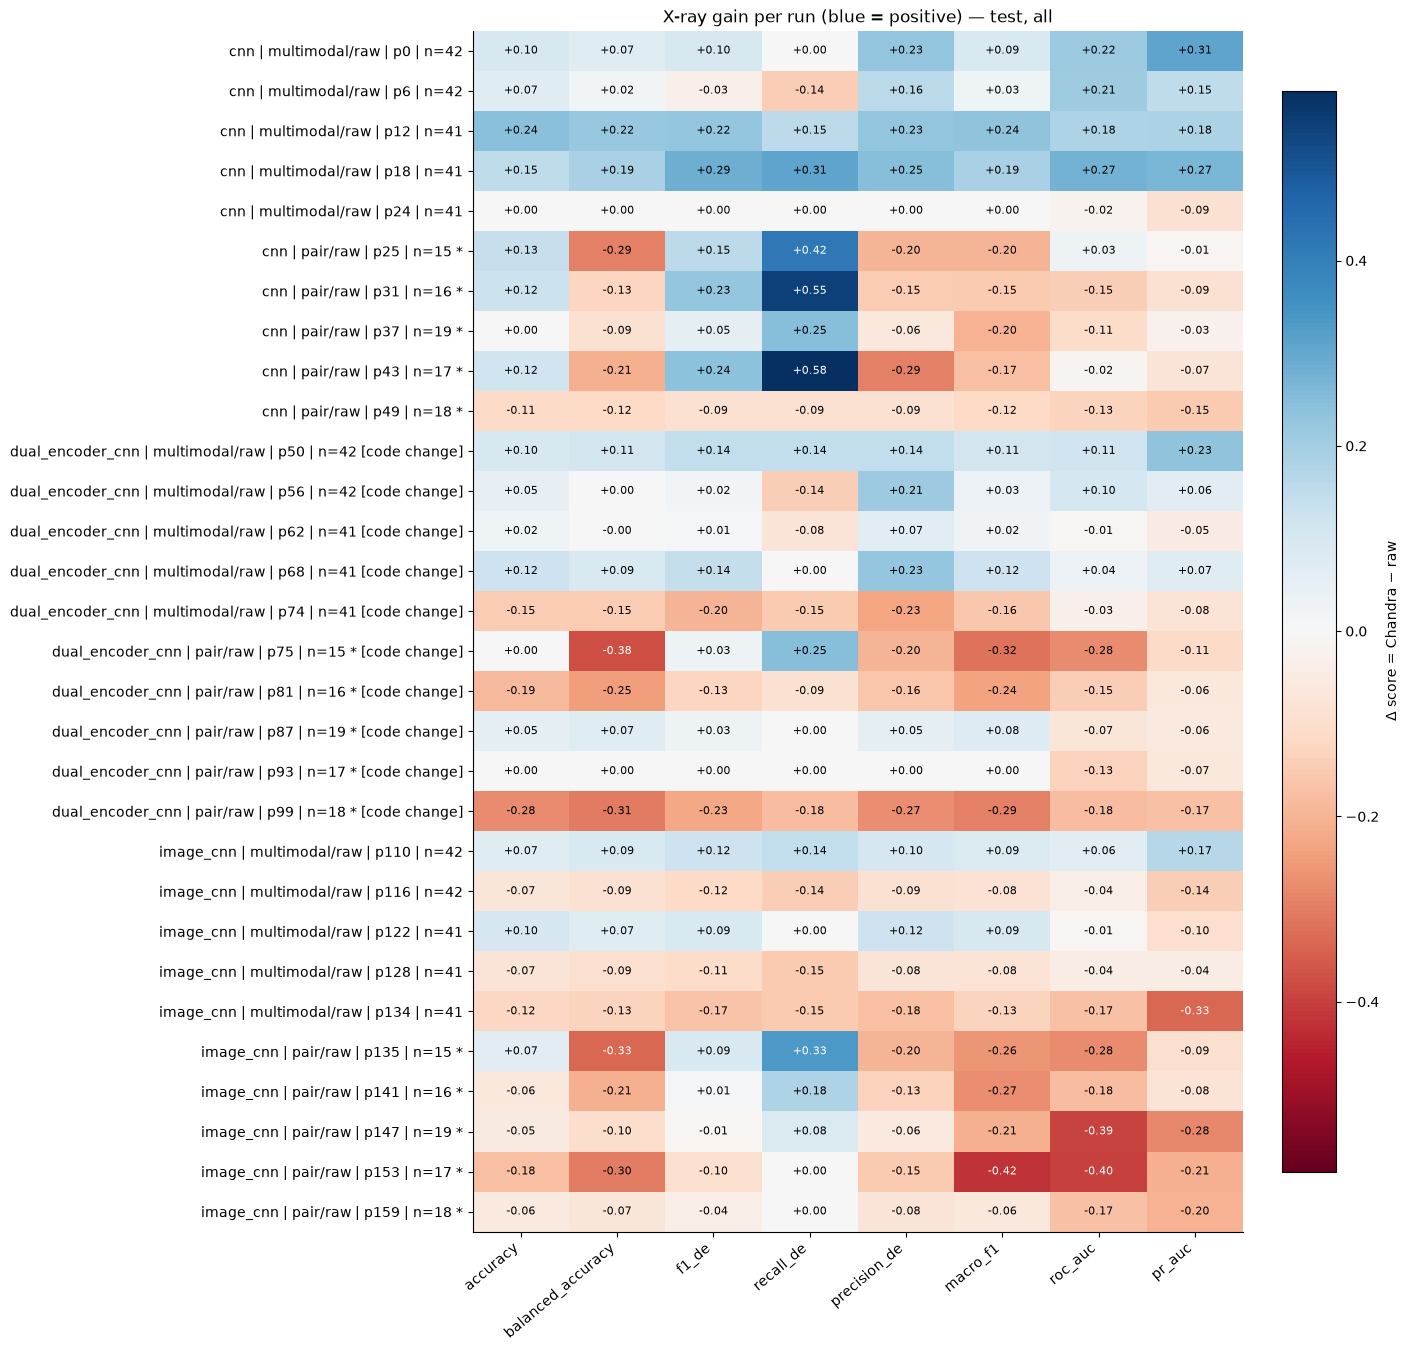

,accuracy,balanced_accuracy,f1_de,recall_de,precision_de,macro_f1,roc_auc,pr_auc
label,,,,,,,,
cnn | multimodal/raw | p0 | n=42,+0.095,+0.071,+0.095,+0.000,+0.229,+0.088,+0.217,+0.306
cnn | multimodal/raw | p6 | n=42,+0.071,+0.018,-0.028,-0.143,+0.158,+0.025,+0.207,+0.149
cnn | multimodal/raw | p12 | n=41,+0.244,+0.220,+0.224,+0.154,+0.232,+0.236,+0.179,+0.183
cnn | multimodal/raw | p18 | n=41,+0.146,+0.190,+0.285,+0.308,+0.250,+0.191,+0.275,+0.268
cnn | multimodal/raw | p24 | n=41,+0.000,+0.000,+0.000,+0.000,+0.000,+0.000,-0.022,-0.091
cnn | pair/raw | p25 | n=15 *,+0.133,-0.292,+0.152,+0.417,-0.200,-0.197,+0.028,-0.014
cnn | pair/raw | p31 | n=16 *,+0.125,-0.127,+0.227,+0.545,-0.146,-0.153,-0.145,-0.089
cnn | pair/raw | p37 | n=19 *,+0.000,-0.089,+0.054,+0.250,-0.061,-0.204,-0.107,-0.027
cnn | pair/raw | p43 | n=17 *,+0.118,-0.208,+0.239,+0.583,-0.294,-0.174,-0.017,-0.074


Row mapping, protocols, and absolute scores:


,pair_index,model,comparison,raw_id,chandra_id,n,n_clusters,split,cohort,controlled,...,chandra_precision_de,macro_f1,raw_macro_f1,chandra_macro_f1,roc_auc,raw_roc_auc,chandra_roc_auc,pr_auc,raw_pr_auc,chandra_pr_auc
0,0,cnn,multimodal/raw,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T144908-e020fce7,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035,42,42,test,all,True,...,0.800000,0.088095,0.678571,0.766667,0.216837,0.663265,0.880102,0.305757,0.529619,0.835376
1,6,cnn,multimodal/raw,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T145839-875586a8,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T150102-41b12da7,42,42,test,all,True,...,0.625000,0.025483,0.605016,0.630499,0.206633,0.591837,0.798469,0.149319,0.467997,0.617317
2,12,cnn,multimodal/raw,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T150458-d65d5679,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T151039-f6ac4e10,41,41,test,all,True,...,0.631579,0.236388,0.558612,0.795000,0.178571,0.717033,0.895604,0.183498,0.536440,0.719938
3,18,cnn,multimodal/raw,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T151554-f2af7ad2,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T151825-a18549bc,41,41,test,all,True,...,0.750000,0.191375,0.607222,0.798596,0.274725,0.587912,0.862637,0.267782,0.502035,0.769817
4,24,cnn,multimodal/raw,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T152320-661d82c0,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T152948-6a95a058,41,41,test,all,True,...,0.600000,0.000000,0.728836,0.728836,-0.021978,0.810440,0.788462,-0.090528,0.661483,0.570955
5,25,cnn,pair/raw,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T144908-e020fce7,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191202-69bd4834,15,15,test,all,False,...,0.800000,-0.196704,0.641148,0.444444,0.027778,0.638889,0.666667,-0.013662,0.914427,0.900765
6,31,cnn,pair/raw,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T145839-875586a8,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191329-0655ce76,16,16,test,all,False,...,0.687500,-0.153377,0.560784,0.407407,-0.145455,0.472727,0.327273,-0.089128,0.741447,0.652319
7,37,cnn,pair/raw,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T150458-d65d5679,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191502-1f6175a3,19,19,test,all,False,...,0.631579,-0.203672,0.590769,0.387097,-0.107143,0.654762,0.547619,-0.026781,0.731743,0.704963
8,43,cnn,pair/raw,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T151554-f2af7ad2,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191624-00c26e9f,17,17,test,all,False,...,0.705882,-0.174442,0.588235,0.413793,-0.016667,0.550000,0.533333,-0.074059,0.832277,0.758218
9,49,cnn,pair/raw,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T152320-661d82c0,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_pair-20261004T191742-bc22430a,18,18,test,all,False,...,0.727273,-0.116883,0.766234,0.649351,-0.129870,0.792208,0.662338,-0.154848,0.864412,0.709564


[code change]: descriptive comparison across different recorded code versions.
Missing baselines or excluded comparisons:


,pair_index,chandra_id,raw_id,model,controlled,differences
0,1,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T145839-875586a8,cnn,False,"split.train, split.validation, split.test"
1,2,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T150458-d65d5679,cnn,False,"split.train, split.validation, split.test"
2,3,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T151554-f2af7ad2,cnn,False,"split.train, split.validation, split.test"
3,4,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T152320-661d82c0,cnn,False,"split.train, split.validation, split.test"
4,5,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T150102-41b12da7,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T144908-e020fce7,cnn,False,"split.train, split.validation, split.test"
...,...,...,...,...,...,...
125,154,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_pair-20261004T193011-028...,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T192326-6594...,image_cnn,False,"split.train, split.validation, split.test"
126,155,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_pair-20261004T193220-374...,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T174858-9c3c...,image_cnn,False,"split.train, split.validation, split.test"
127,156,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_pair-20261004T193220-374...,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T181239-a029...,image_cnn,False,"split.train, split.validation, split.test"
128,157,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_pair-20261004T193220-374...,/Users/antoinegdrn/PH_Project_I/results/clusterprep/image_cnn/image_cnn_raw-20261003T183823-e3bc...,image_cnn,False,"split.train, split.validation, split.test"


In [9]:
GAIN_SPLIT = 'test'  # 'validation' or 'test'
GAIN_COHORT = 'all'  # 'all', 'paired' or 'raw_only'
INCLUDE_PAIR_RAW = True
GAIN_ALLOW_CODE_CHANGE_MODELS = ('dual_encoder_cnn',)  # Explicit descriptive comparison across code versions.
GAIN_ANNOTATE = True
GAIN_COLOR_LIMIT = None  # None: automatic symmetric scale; e.g. 0.7 to fix the range at ±0.7.

gain_matrix, gain_details, gain_issues = gain_tables(
    selected, split=GAIN_SPLIT, cohort=GAIN_COHORT, include_pair=INCLUDE_PAIR_RAW,
    allow_code_change_models=GAIN_ALLOW_CODE_CHANGE_MODELS)
gain_figure = None
if gain_matrix.empty:
    print('No compatible comparisons for this selection/cohort. See exclusions.')
else:
    gain_figure = plot_gain_heatmap(
        gain_matrix,
        title=f'X-ray gain per run (blue = positive) — {GAIN_SPLIT}, {GAIN_COHORT}',
        annotate=GAIN_ANNOTATE, limit=GAIN_COLOR_LIMIT)
    plt.show()
    display(gain_matrix.style.format('{:+.3f}', na_rep='N/A'))
    print('Row mapping, protocols, and absolute scores:')
    display(gain_details)
    if gain_details.code_changed.any():
        print('[code change]: descriptive comparison across different recorded code versions.')
if not gain_issues.empty:
    print('Missing baselines or excluded comparisons:')
    display(gain_issues)


### Uncertainty interval for a selected pair

Choose `PAIR_INDEX` from the catalog (index shown on the left). Default: the first controlled pair. The bootstrap resamples **clusters** in a paired manner and recomputes metrics using exactly the same draws for both models. The 95% percentile interval describes sampling uncertainty conditional on the two trained models; it does not cover variability across seeds or multiple comparisons.

`delta = with Chandra − without Chandra`. Positive deltas are favorable for scores; negative deltas are favorable for log loss/Brier. Score deltas × 100 give **percentage points**, not relative improvement. Draws with undefined AUC are excluded for that metric, and the valid count is reported. An interval containing zero is inconclusive. Interpret intervals cautiously when few clusters are available.

Uncontrolled pairs are rejected by default. `ALLOW_EXPLORATORY=True` allows a descriptive comparison on shared clusters with differences displayed; the gain cannot then be attributed to Chandra alone.

,selected pair
chandra_id,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_multimodal-20261003T145149-4b7a0035
raw_id,/Users/antoinegdrn/PH_Project_I/results/clusterprep/cnn/cnn_raw-20261003T144908-e020fce7
model,cnn
controlled,True
differences,


,metric,raw,chandra,delta,gain_oriented,ci_low,ci_high,valid_bootstrap,n,n_clusters,cohort
0,accuracy,0.666667,0.666667,0.000000,0.000000,-0.200000,0.200000,500,15,15,paired
1,balanced_accuracy,0.791667,0.666667,-0.125000,-0.125000,-0.500000,0.125000,500,15,15,paired
2,macro_f1,0.641148,0.603175,-0.037974,-0.037974,-0.296053,0.149532,500,15,15,paired
3,weighted_f1,0.698565,0.698413,-0.000152,-0.000152,-0.211483,0.179336,500,15,15,paired
4,roc_auc_macro,0.638889,0.694444,0.055556,0.055556,-0.333333,0.340341,484,15,15,paired
5,average_precision_macro,0.608999,0.729549,0.120550,0.120550,-0.117304,0.357856,484,15,15,paired
6,log_loss,0.649002,0.522698,-0.126304,0.126304,-0.267262,0.071854,500,15,15,paired
7,brier,0.457337,0.355123,-0.102213,0.102213,-0.220385,0.071719,500,15,15,paired


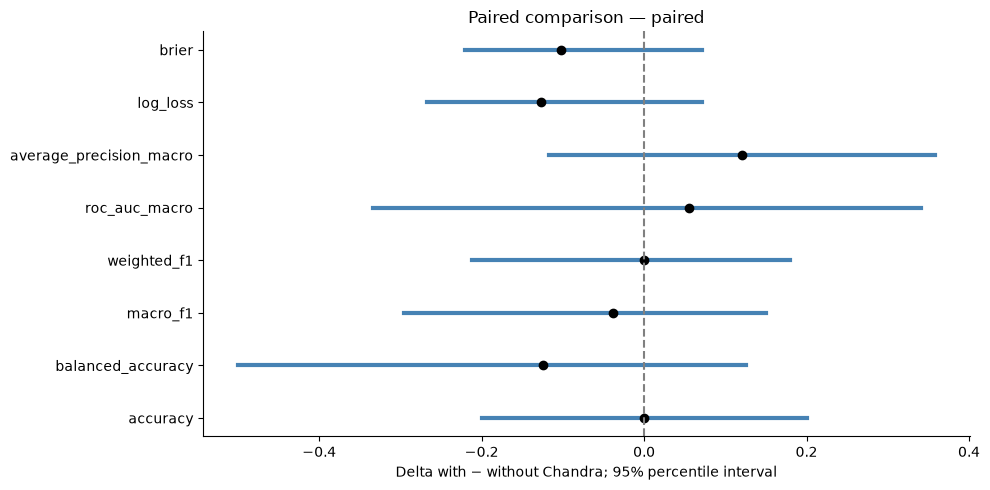

In [10]:
PAIR_INDEX = None  # Example: 0, 1, ... (pair_catalog index)
PAIR_COHORT = 'paired'  # Compare the same clusters with Chandra observations.
BOOTSTRAP = 500        # 2000+ for a final report.
ALLOW_EXPLORATORY = False
paired_uncertainty = pd.DataFrame()
if PAIR_INDEX is None and not controlled_pairs.empty:
    PAIR_INDEX = controlled_pairs.index[0]
if PAIR_INDEX is None:
    print('No controlled pair: check the catalog and select a compatible raw baseline.')
else:
    pair = pair_catalog.loc[PAIR_INDEX]
    display(pair.to_frame('selected pair'))
    if pd.isna(pair.raw_id):
        print('No baseline without Chandra available.')
    elif not pair.controlled and not ALLOW_EXPLORATORY:
        print('Comparison rejected: different protocol. See differences.')
    else:
        if not pair.controlled:
            print('EXPLORATORY: Chandra effect not isolated —', pair.differences)
        try:
            paired_uncertainty = paired_delta(runs[pair.raw_id], runs[pair.chandra_id],
                                              cohort=PAIR_COHORT, n_boot=BOOTSTRAP)
            display(paired_uncertainty)
            fig, ax = plt.subplots(figsize=(10, 5))
            for i, row in paired_uncertainty.iterrows():
                ax.plot([row.ci_low, row.ci_high], [i, i], color='steelblue', lw=3)
                ax.plot(row.delta, i, 'o', color='black')
            ax.axvline(0, color='gray', ls='--')
            ax.set(yticks=range(len(paired_uncertainty)), yticklabels=paired_uncertainty.metric,
                   xlabel='Delta with − without Chandra; 95% percentile interval',
                   title=f'Paired comparison — {PAIR_COHORT}')
            fig.tight_layout()
            plt.show()
        except (ValueError, OSError) as exc:
            print(f'Comparison unavailable: {exc}')


## 5. Reproducible exports and interpretation

Set `EXPORT=True` in the configuration and rerun this cell. Tables are exported to a directory separate from the training runs. The exact selection, criterion, cohort, and bootstrap settings are recorded. The gain heatmap is exported as PNG and PDF, alongside its CSV table.

To select a model, first examine validation candidates on the same cohort, then per-class recall/F1, calibration, learning-curve stability, cost, and finally test results. Repeat training with multiple seeds before claiming robust superiority. Repetitions with the same seed are not independent folds.

In [11]:
if EXPORT:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    tables = {'xray_gain_details': gain_details, 'xray_gain_issues': gain_issues,
              'xray_gain': gain_matrix.rename_axis('comparison').reset_index(),
              'inventory': inventory, 'ranking_validation': ranking, 'test': test_table,
              'configurations': config_table.reset_index(names='run_name'), 'chandra_pairs': pair_catalog,
              'chandra_deltas': chandra_deltas, 'paired_uncertainty': paired_uncertainty,
              'loading_issues': loading_issues, 'validation_issues': validation_issues,
              'validation_protocols': validation_protocols, 'test_protocols': test_protocols,
              'test_issues': test_issues, 'chandra_issues': pd.DataFrame(delta_issues)}
    for name, table in tables.items():
        table.to_csv(EXPORT_DIR / f'{name}.csv', index=False)
    if gain_figure is not None:
        gain_figure.savefig(EXPORT_DIR / 'xray_gain.png', dpi=180, bbox_inches='tight')
        gain_figure.savefig(EXPORT_DIR / 'xray_gain.pdf', bbox_inches='tight')
    manifest = dict(gain_allow_code_change_models=list(GAIN_ALLOW_CODE_CHANGE_MODELS),
                    gain_split=GAIN_SPLIT, gain_cohort=GAIN_COHORT,
                    include_pair_raw=INCLUDE_PAIR_RAW, gain_color_limit=GAIN_COLOR_LIMIT,
                    selected_runs=selected_ids, roots=list(map(str, RESULT_ROOTS)),
                    rank_metric=RANK_METRIC, cohort=COHORT, common_samples=COMMON_SAMPLES,
                    pair_index=None if PAIR_INDEX is None else int(PAIR_INDEX), pair_cohort=PAIR_COHORT,
                    bootstrap=BOOTSTRAP, bootstrap_seed=42, allow_exploratory=ALLOW_EXPLORATORY)
    (EXPORT_DIR / 'selection.json').write_text(json.dumps(manifest, indent=2), encoding='utf-8')
    print(f'Reports exported: {EXPORT_DIR}')
else:
    print('Export disabled. Set EXPORT=True to save the tables.')


Export disabled. Set EXPORT=True to save the tables.
